# Importing Required Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import shap
import joblib

# Loading Dataset

In [3]:
df_Industrial_Equipment = pd.read_csv('ai4i2020.csv')
df_Industrial_Equipment.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df_Industrial_Equipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

# Checking Missing Values

In [5]:
missing_values = df_Industrial_Equipment.isnull().sum()

print("Missing Values in Each Column:")
missing_values

Missing Values in Each Column:


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


# Checking Duplicate Rows

In [6]:
duplicate_rows = df_Industrial_Equipment.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


# Exploratory Data Analysis

# Descriptive Statistics

In [8]:
descriptive_statistics = df_Industrial_Equipment.describe().T
descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


# Distribution of Machine Failure Status

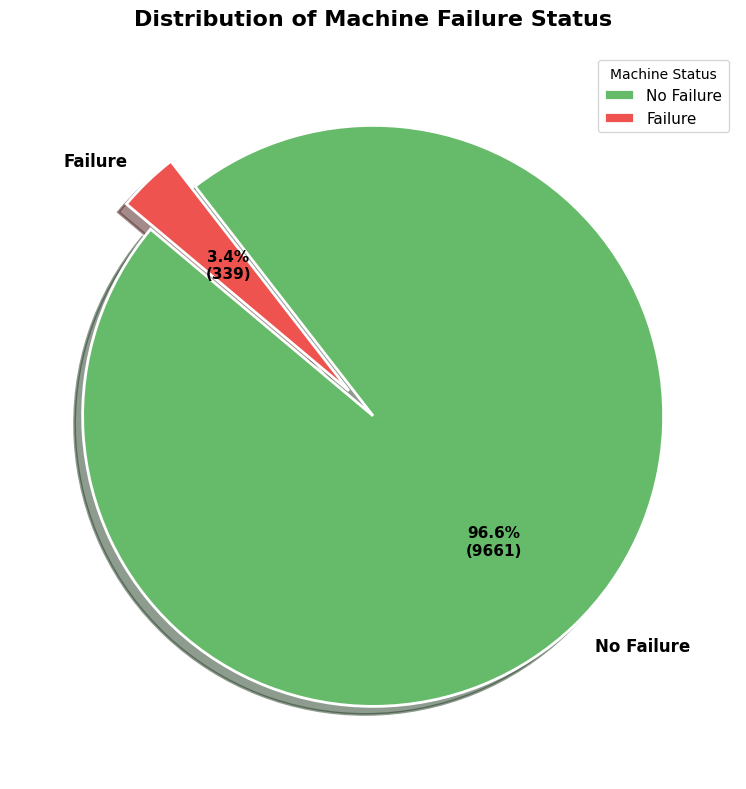

In [10]:
failure_counts = df_Industrial_Equipment['Machine failure'].value_counts().sort_index()

labels = ['No Failure', 'Failure']

colors = ['#66BB6A', '#EF5350']

explode = (0, 0.12)

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    failure_counts,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100*failure_counts.sum()))})',
    startangle=140,
    shadow=True,
    textprops={'fontsize':12, 'weight':'bold'},
    wedgeprops={'edgecolor':'white','linewidth':2}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.title(
    'Distribution of Machine Failure Status',
    fontsize=16,
    weight='bold',
    pad=20
)

plt.legend(
    wedges,
    labels,
    title="Machine Status",
    loc="upper right",
    fontsize=11
)

plt.tight_layout()
plt.show()

# Average Tool Wear by Product Type

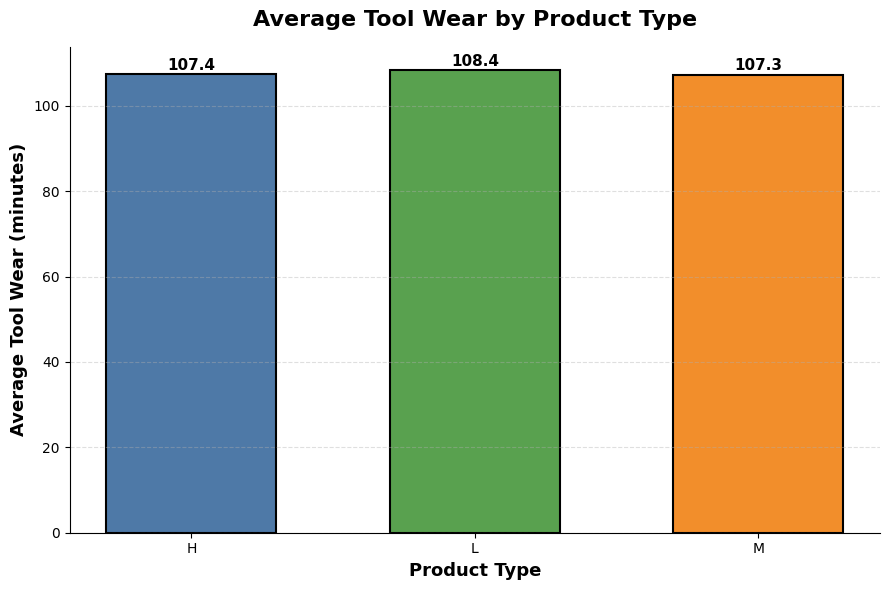

In [12]:
# Calculate average tool wear
avg_toolwear = (
    df_Industrial_Equipment
    .groupby('Type')['Tool wear [min]']
    .mean()
    .sort_index()
)

# Colours
colors = ['#4E79A7', '#59A14F', '#F28E2B']

plt.figure(figsize=(9,6))

bars = plt.bar(
    avg_toolwear.index,
    avg_toolwear.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    width=0.6
)

# Data Labels
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 1,
        f'{y:.1f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Average Tool Wear by Product Type',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Product Type',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Average Tool Wear (minutes)',
    fontsize=13,
    fontweight='bold'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Average Air Temperature Across Tool Wear Intervals

/tmp/ipykernel_3009/1115352226.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(toolwear_bins)['Air temperature [K]']


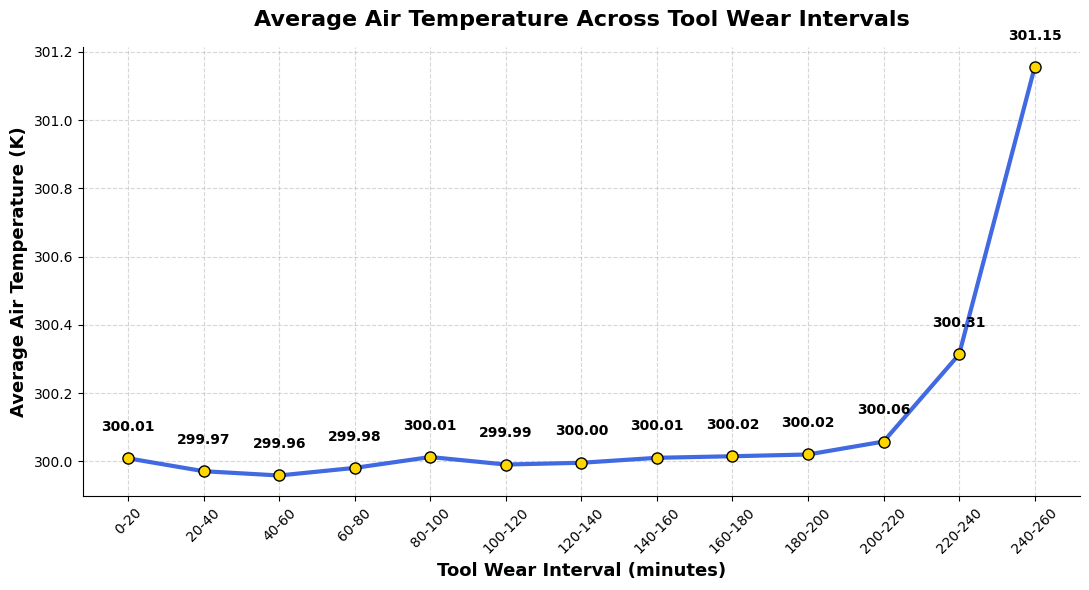

In [13]:
# Creating Tool Wear Groups (20-minute intervals)
toolwear_bins = pd.cut(
    df_Industrial_Equipment['Tool wear [min]'],
    bins=range(0, 261, 20)
)

# Calculating Average Air Temperature for each interval
avg_air_temp = (
    df_Industrial_Equipment
    .groupby(toolwear_bins)['Air temperature [K]']
    .mean()
)

x_labels = [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avg_air_temp.index]

plt.figure(figsize=(11,6))

plt.plot(
    x_labels,
    avg_air_temp.values,
    marker='o',
    markersize=8,
    linewidth=3,
    color='royalblue',
    markerfacecolor='gold',
    markeredgecolor='black'
)

for x, y in zip(x_labels, avg_air_temp.values):
    plt.text(
        x,
        y + 0.08,
        f'{y:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Average Air Temperature Across Tool Wear Intervals',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Tool Wear Interval (minutes)',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Average Air Temperature (K)',
    fontsize=13,
    fontweight='bold'
)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Remove top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Distribution of Torque Values

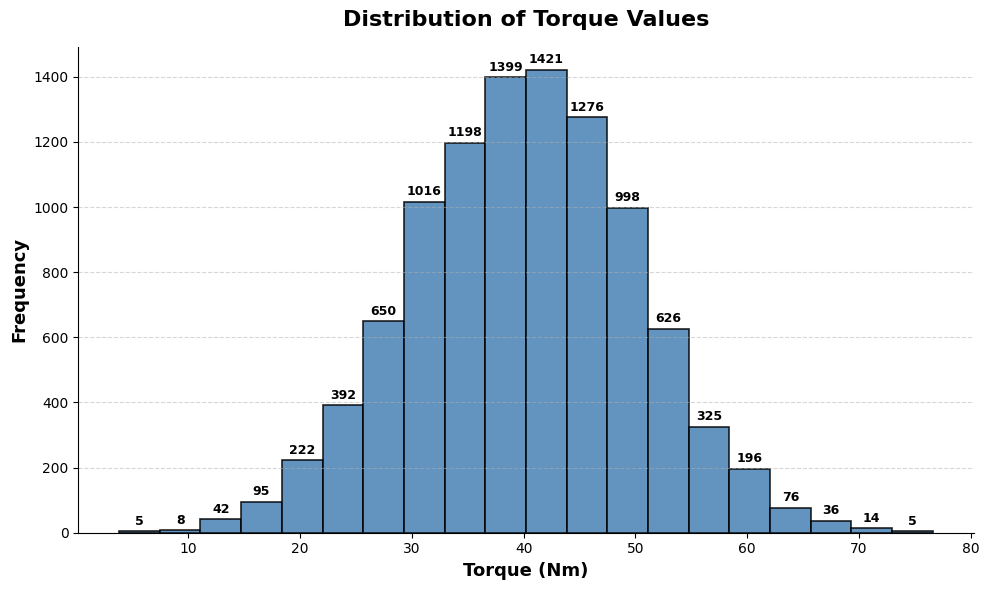

In [14]:
plt.figure(figsize=(10,6))

counts, bins, patches = plt.hist(
    df_Industrial_Equipment['Torque [Nm]'],
    bins=20,
    color='steelblue',
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85
)

for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        plt.text(
            (left + right) / 2,
            count + 20,
            f'{int(count)}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

plt.title(
    'Distribution of Torque Values',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Torque (Nm)',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Frequency',
    fontsize=13,
    fontweight='bold'
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

# Correlation Matrix

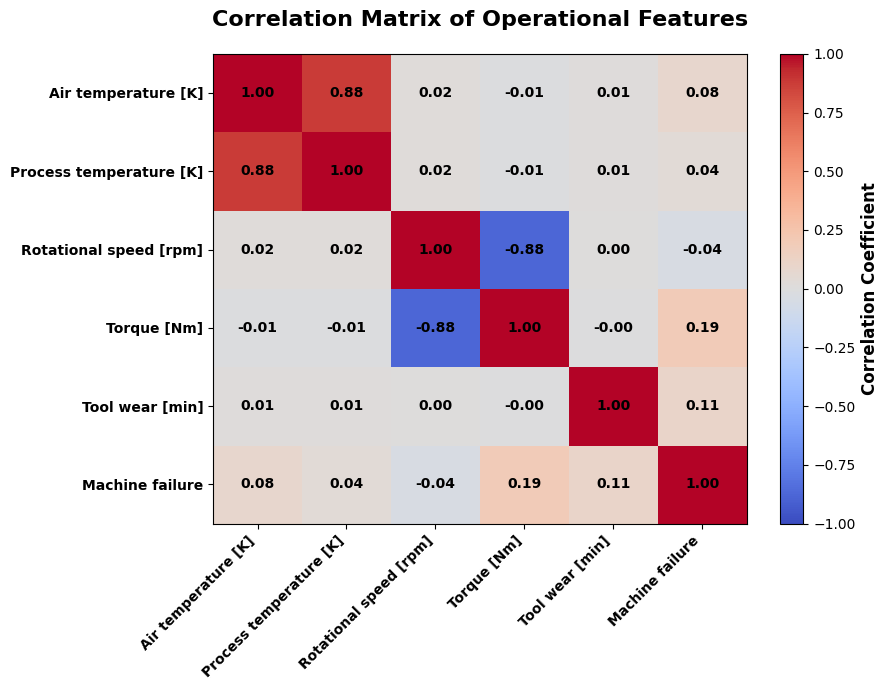

In [15]:
correlation_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

correlation_matrix = df_Industrial_Equipment[correlation_features].corr()

plt.figure(figsize=(9,7))

image = plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    interpolation='nearest',
    aspect='auto',
    vmin=-1,
    vmax=1
)

cbar = plt.colorbar(image)
cbar.set_label('Correlation Coefficient', fontsize=12, fontweight='bold')

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha='right',
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features,
    fontsize=10,
    fontweight='bold'
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

plt.title(
    'Correlation Matrix of Operational Features',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

plt.show()

# Data Preprocessing

In [17]:
# Creating a copy of the dataset
df_preprocessed = df_Industrial_Equipment.copy()

#  Droping Identifier Columns
# UDI and Product ID are unique identifiers and do
# not contribute to machine failure prediction.

df_preprocessed.drop(
    columns=['UDI', 'Product ID'],
    inplace=True
)

#  Encoding Categorical Feature
# Convert Product Type (L, M, H) into numerical values.

label_encoder = LabelEncoder()

df_preprocessed['Type'] = label_encoder.fit_transform(
    df_preprocessed['Type']
)

#  Removing Failure Mode Columns
# These columns reveal the reason for machine failure
# and may cause target leakage.

df_preprocessed.drop(
    columns=['TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
    inplace=True
)


# Separating Features and Target Variable

X = df_preprocessed.drop(columns=['Machine failure'])

y = df_preprocessed['Machine failure']

In [19]:

#  Spliting Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#  Feature Scaling


scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)


# Model 1: Decision Tree Classifier

In [21]:

#  Train Decision Tree Classifier

decision_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    random_state=42
)

decision_tree.fit(X_train_scaled, y_train)

# Model Prediction


y_pred = decision_tree.predict(X_test_scaled)
y_prob = decision_tree.predict_proba(X_test_scaled)[:, 1]


#  Model Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*60)
print("Decision Tree Classifier Performance")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print("="*60)
print(classification_report(y_test, y_pred))


Decision Tree Classifier Performance
Accuracy : 0.9755
Precision: 0.7879
Recall   : 0.3824
F1-Score : 0.5149
ROC-AUC  : 0.9219

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.79      0.38      0.51        68

    accuracy                           0.98      2000
   macro avg       0.88      0.69      0.75      2000
weighted avg       0.97      0.98      0.97      2000



# Confusion Matrix for Decision Tree

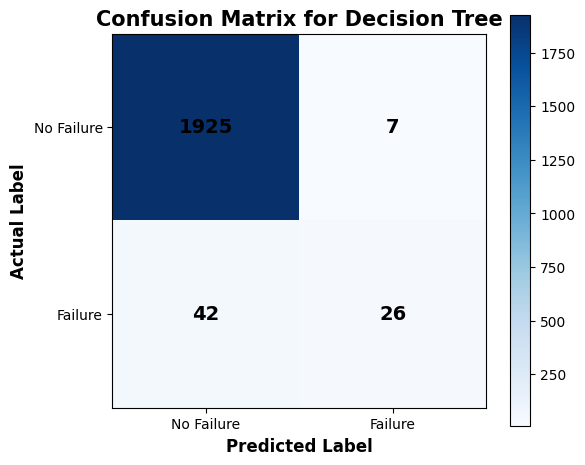

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

plt.title(
    "Confusion Matrix for Decision Tree",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Actual Label",
    fontsize=12,
    fontweight='bold'
)

plt.xticks([0,1],["No Failure","Failure"])
plt.yticks([0,1],["No Failure","Failure"])

# Data labels
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i,j]),
            ha='center',
            va='center',
            fontsize=14,
            fontweight='bold',
            color='black'
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ROC Curve for Decision Tree Classifier

<Figure size 700x600 with 0 Axes>

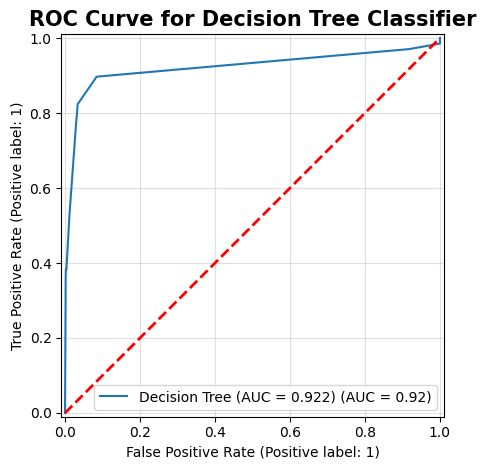

In [24]:
plt.figure(figsize=(7,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name=f"Decision Tree (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    color='red'
)

plt.title(
    "ROC Curve for Decision Tree Classifier",
    fontsize=15,
    fontweight='bold'
)

plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Model 2: Random Forest

In [26]:
#  Train Random Forest Classifier


rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)


#  Prediction


rf_predictions = rf_model.predict(X_test_scaled)
rf_probability = rf_model.predict_proba(X_test_scaled)[:,1]


#  Model Evaluation

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probability)

print("="*60)
print("Random Forest Classifier Performance")
print("="*60)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\nClassification Report for Random Forest")
print("="*60)

print(classification_report(y_test, rf_predictions))

Random Forest Classifier Performance
Accuracy : 0.9845
Precision: 0.8936
Recall   : 0.6176
F1-Score : 0.7304
ROC-AUC  : 0.9715

Classification Report for Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.62      0.73        68

    accuracy                           0.98      2000
   macro avg       0.94      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



# Confusion Matrix for Random Forest

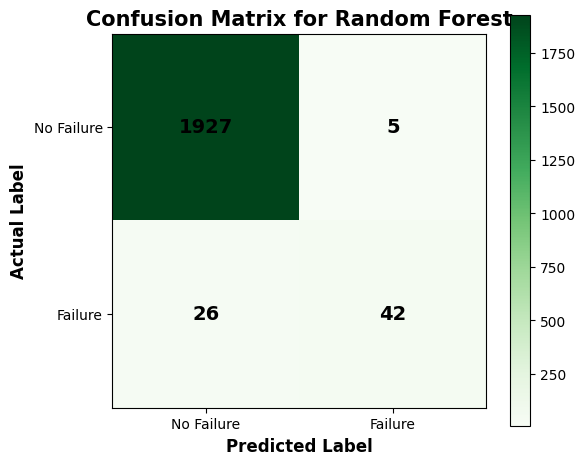

In [29]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

plt.imshow(rf_cm, cmap='Greens')

plt.title(
    "Confusion Matrix for Random Forest",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Actual Label",
    fontsize=12,
    fontweight='bold'
)

plt.xticks([0,1],["No Failure","Failure"])
plt.yticks([0,1],["No Failure","Failure"])

# Cell labels

for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(
            j,
            i,
            str(rf_cm[i,j]),
            ha='center',
            va='center',
            fontsize=14,
            fontweight='bold'
        )

plt.colorbar()

plt.tight_layout()

plt.show()

# ROC Curve for Random Forest Classifier

<Figure size 700x600 with 0 Axes>

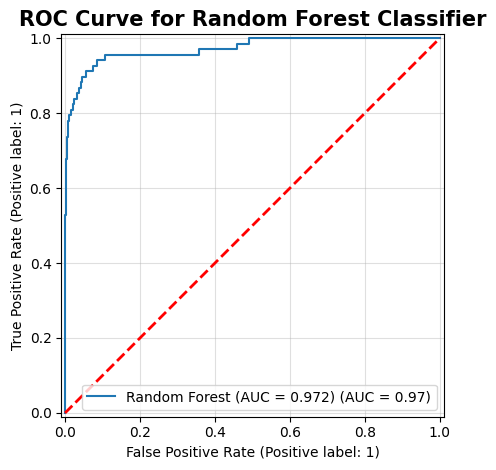

In [30]:
plt.figure(figsize=(7,6))

RocCurveDisplay.from_predictions(
    y_test,
    rf_probability,
    name=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red',
    linewidth=2
)

plt.title(
    "ROC Curve for Random Forest Classifier",
    fontsize=15,
    fontweight='bold'
)

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

# Model 3: XGBoost Classifier

In [32]:
#  Train XGBoost Classifier


xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

#  Prediction


xgb_predictions = xgb_model.predict(X_test_scaled)

xgb_probability = xgb_model.predict_proba(X_test_scaled)[:,1]

#  Model Evaluation

xgb_accuracy = accuracy_score(y_test, xgb_predictions)

xgb_precision = precision_score(y_test, xgb_predictions)

xgb_recall = recall_score(y_test, xgb_predictions)

xgb_f1 = f1_score(y_test, xgb_predictions)

xgb_auc = roc_auc_score(y_test, xgb_probability)

print("="*60)
print("XGBoost Classifier Performance")
print("="*60)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

print("\nClassification Report for XGBoost")
print("="*60)

print(classification_report(y_test, xgb_predictions))


XGBoost Classifier Performance
Accuracy : 0.9845
Precision: 0.9111
Recall   : 0.6029
F1-Score : 0.7257
ROC-AUC  : 0.9757

Classification Report for XGBoost
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.60      0.73        68

    accuracy                           0.98      2000
   macro avg       0.95      0.80      0.86      2000
weighted avg       0.98      0.98      0.98      2000



# XGBoost Confusion Matrix

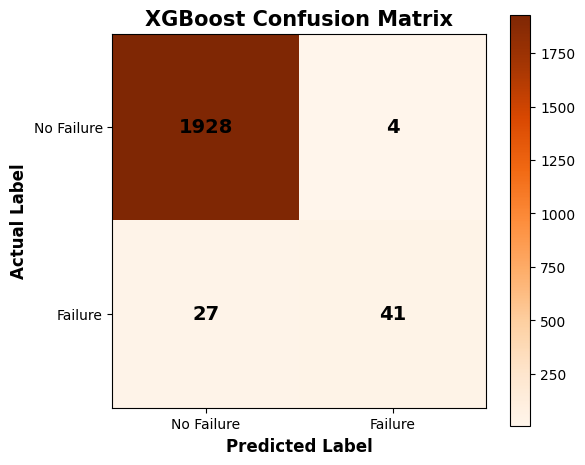

In [33]:
xgb_cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(6,5))

plt.imshow(xgb_cm, cmap='Oranges')

plt.title(
    "XGBoost Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Actual Label",
    fontsize=12,
    fontweight='bold'
)

plt.xticks([0,1],["No Failure","Failure"])

plt.yticks([0,1],["No Failure","Failure"])

for i in range(xgb_cm.shape[0]):
    for j in range(xgb_cm.shape[1]):
        plt.text(
            j,
            i,
            str(xgb_cm[i,j]),
            ha='center',
            va='center',
            fontsize=14,
            fontweight='bold'
        )

plt.colorbar()

plt.tight_layout()

plt.show()


# ROC Curve - XGBoost Classifier

<Figure size 700x600 with 0 Axes>

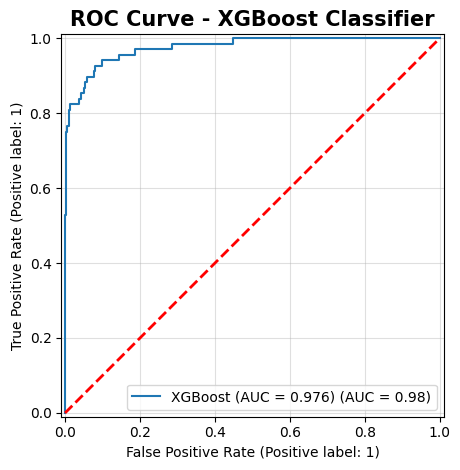

In [34]:
plt.figure(figsize=(7,6))

RocCurveDisplay.from_predictions(
    y_test,
    xgb_probability,
    name=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    color='red'
)

plt.title(
    "ROC Curve - XGBoost Classifier",
    fontsize=15,
    fontweight='bold'
)

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

# Model Comparison

In [35]:
model_comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],

    "F1-Score": [
        f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        roc_auc,
        rf_auc,
        xgb_auc
    ]

})

# Round values
model_comparison = model_comparison.round(4)

print("="*80)
print("Machine Learning Model Performance Comparison")
print("="*80)

model_comparison

Machine Learning Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.9755,0.7879,0.3824,0.5149,0.9219
1,Random Forest,0.9845,0.8936,0.6176,0.7304,0.9715
2,XGBoost,0.9845,0.9111,0.6029,0.7257,0.9757


In [36]:
best_model = model_comparison.loc[
    model_comparison["ROC-AUC"].idxmax()
]

print("="*60)
print("Best Performing Model")
print("="*60)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

Best Performing Model
Model      : XGBoost
Accuracy   : 0.9845
Precision  : 0.9111
Recall     : 0.6029
F1-Score   : 0.7257
ROC-AUC    : 0.9757


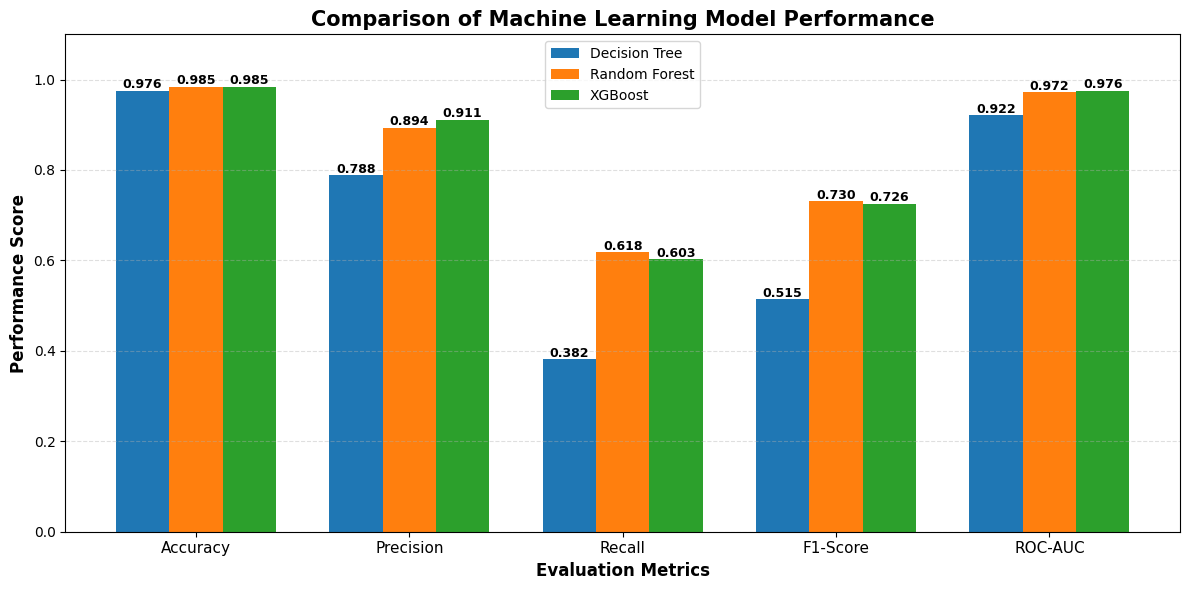

In [37]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

decision_tree_scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

random_forest_scores = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc
]

xgboost_scores = [
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_auc
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))

bars1 = plt.bar(
    x - width,
    decision_tree_scores,
    width,
    label="Decision Tree"
)

bars2 = plt.bar(
    x,
    random_forest_scores,
    width,
    label="Random Forest"
)

bars3 = plt.bar(
    x + width,
    xgboost_scores,
    width,
    label="XGBoost"
)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f"{height:.3f}",
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

plt.xticks(x, metrics, fontsize=11)

plt.ylabel(
    "Performance Score",
    fontsize=12,
    fontweight='bold'
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=12,
    fontweight='bold'
)

plt.title(
    "Comparison of Machine Learning Model Performance",
    fontsize=15,
    fontweight='bold'
)

plt.ylim(0, 1.10)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend()

plt.tight_layout()

plt.show()

# Explainable AI (XAI) using SHAP

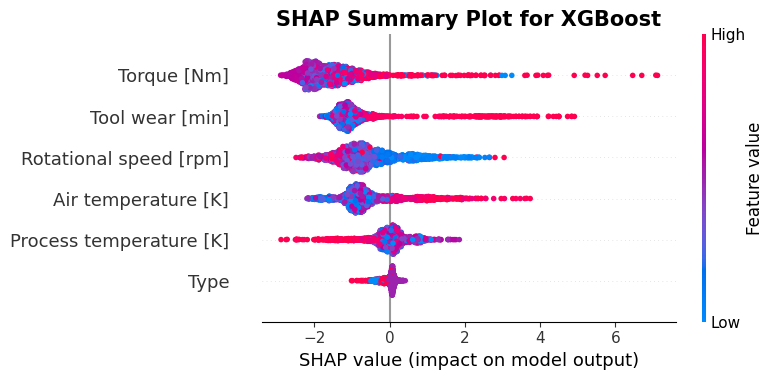

In [39]:
# Initialize SHAP JavaScript visualization
shap.initjs()

# Creating SHAP Explainer


explainer = shap.TreeExplainer(xgb_model)

# Calculating SHAP values
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    show=False
)

plt.title(
    "SHAP Summary Plot for XGBoost",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# SHAP Feature Importance

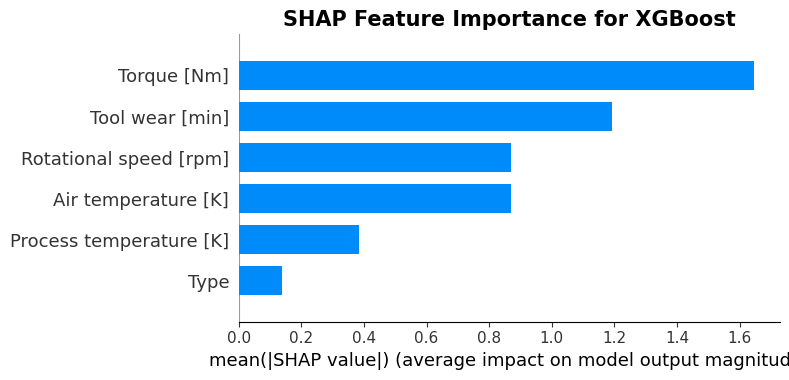

In [40]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance for XGBoost",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# SHAP Waterfall Plot

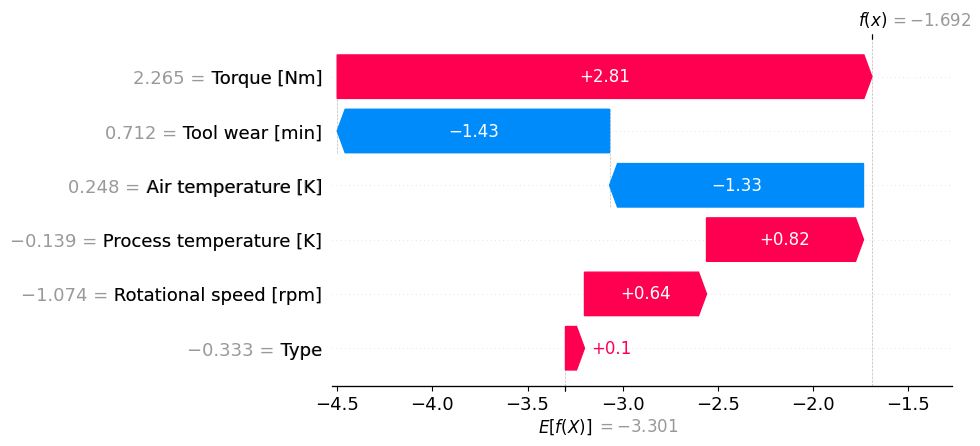

In [42]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[sample_index],
        feature_names=X.columns
    )
)

# Saving the Best Model

In [44]:
joblib.dump(xgb_model, "Best_XGBoost_Model.pkl")

joblib.dump(scaler, "Feature_Scaler.pkl")

print("="*60)
print("Model Saved Successfully")
print("="*60)
print("Saved Model : Best_XGBoost_Model.pkl")
print("Saved Scaler: Feature_Scaler.pkl")

Model Saved Successfully
Saved Model : Best_XGBoost_Model.pkl
Saved Scaler: Feature_Scaler.pkl


In [47]:

# Prototype Testing with Manual Input

import joblib
import pandas as pd


# Loading Saved Model and Scaler


loaded_model = joblib.load("Best_XGBoost_Model.pkl")
loaded_scaler = joblib.load("Feature_Scaler.pkl")


# Manual Input


print("="*60)
print("Enter Machine Details")
print("="*60)

machine_type = int(input("Type (0 = L, 1 = M, 2 = H): "))

air_temp = float(input("Air Temperature [K]: "))

process_temp = float(input("Process Temperature [K]: "))

rotational_speed = float(input("Rotational Speed [rpm]: "))

torque = float(input("Torque [Nm]: "))

tool_wear = float(input("Tool Wear [min]: "))


# Creating DataFrame


manual_input = pd.DataFrame({

    "Type":[machine_type],
    "Air temperature [K]":[air_temp],
    "Process temperature [K]":[process_temp],
    "Rotational speed [rpm]":[rotational_speed],
    "Torque [Nm]":[torque],
    "Tool wear [min]":[tool_wear]

})

print("\n")

print("="*60)
print("Machine Input")
print("="*60)

display(manual_input)


# Scale Data


manual_scaled = loaded_scaler.transform(manual_input)


# Prediction

prediction = loaded_model.predict(manual_scaled)

prediction_probability = loaded_model.predict_proba(manual_scaled)


# Display Result

print("\n")

print("="*60)
print("Prediction Result")
print("="*60)

if prediction[0] == 1:

    print("Machine Failure Predicted")

else:

    print("No Machine Failure Predicted")

print("\nProbability of No Failure : {:.2f}%".format(
    prediction_probability[0][0] * 100
))

print("Probability of Failure    : {:.2f}%".format(
    prediction_probability[0][1] * 100
))

Enter Machine Details
Type (0 = L, 1 = M, 2 = H): 2
Air Temperature [K]: 304
Process Temperature [K]: 314
Rotational Speed [rpm]: 1150
Torque [Nm]: 70
Tool Wear [min]: 250


Machine Input


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,304.0,314.0,1150.0,70.0,250.0




Prediction Result
Machine Failure Predicted

Probability of No Failure : 1.20%
Probability of Failure    : 98.80%
